<h1 style="text-align: center; font-family: 'menlo'; color: #ADD8E6; font-size:50px;">
  <span style="background-color: #191970; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Overscan
  </span>
</h1>

The overscan region of a CCD, if present, is a part of the chip that is covered. Depending on the camera, it can be a useful way to remove small variations in the bias level from frame to frame.

However, whether or not the overscan is useful depends on the camera. It’s advisable to examine the overscan part of the camera you’re using before deciding if you should include it in image reduction.

One important note: <u>overscan always includes bias, read noise, and dark current.</u> The overscan pixels are still pixels, and just like any other pixel includes dark current and is subject to read noise. Many sources describe overscan as correcting for bias, but if the dark current for the camera is negligible, as it often is for cryogenically cooled cameras, then the overscan is essentially bias.

*Serve para remover pequenas variações no nível de bias de uma imagem pra outra. O nível de bias pode variar um pouco entre frames, e o overscan ajuda a ajustar isso.*

The read noise in the overscan is reduced by averaging over the overscan region. That will be covered in a later notebook; this notebook focuses on <u>what the overscan looks like and how to decide whether or not to use it.</u>

In this notebook we will look at the overscan region for two different cameras, a cryogenically cooled camera in which the overscan provides useful information and a thermo-electrically cooled camera in which the overscan does not provide useful information.

*Se a dark current for negligenciável (câmeras criogenicamente resfriadas), aí o overscan é essencialmente bias. Caso contrário, o overscan tem dark current também.*

In [11]:
from pathlib import Path #biblioteca padrão do Python para trabalhar com caminhos de arquivos (pastas e arquivos no computador).

from astropy.nddata import CCDData #armazenar dados de CCD, ler e guardar imagens FITS com metadados
from astropy.visualization import hist #histogramas
from ccdproc import subtract_overscan 
#função principal deste notebook: calcula o valor médio (ou mediana) da região de overscan e subtrai esse valor de toda a imagem, é da biblioteca ccdproc
import matplotlib.pyplot as plt #plot de gráfico

from convenience_functions import show_image

# Use custom style for larger fonts and figures
plt.style.use('guide.mplstyle')

# Case 1: Cryogenically cooled Large Format Camera (LFC) at Palomar

The images below are from chip 0 of the LFC at the Palomar 200-inch telescope. Technical information about the camera is [here.](https://sites.astro.caltech.edu/palomar/observer/200inchResources/lfcspecs.html) It turns out that the images are not actually 2048 × 4096; as you can see below, the images are 2080 × 4128. The “extra” in each direction is overscan.

The FITS header for these files includes the <u>keyword BIASSEC, which indicates the nominal extent of the overscan region.</u> Its value is [2049:2080,1:4127], which indicates the overscan extends from 2048 to 2079 <u>(Python indexing starts at 0, not 1 like in FITS)</u> in the “short” direction and over the entire chip in the other direction. As we’ll see shortly, the useful overscan region is smaller than this.

We’ll focus here on the overscan in the side that is nominally 2048 wide; in Python that’s the second index. The pixel count cross-sections plotted below are from a bias, science, and flat image. Flat images are particularly helpful in evaluating how much of the overscan region is useful because the average pixel value in the exposed part of the camera is typically large.

In [14]:
cryo_path = Path('example-cryo-LFC') #cria um objeto Path apontando para a pasta example-cryo-LFC, é onde estão os arquivos FITS da câmera LFC

bias_lfc = CCDData.read(cryo_path / 'ccd.001.0.fits', unit='count') #lê a imagem de bias (exposição zero, obturador fechado), unit='count' diz que os valores são contagens (ADU/counts)

science_g_lfc = CCDData.read(cryo_path / 'ccd.037.0.fits', unit='count') #lê a imagem de ciência (objeto astronômico real, filtro g).

flat_g_lfc = CCDData.read(cryo_path / 'ccd.014.0.fits', unit='count') #lê a imagem de flat

#carrega 3 imagens do mesmo chip: bias, ciência e flat. Todas são CCDData, que guardam os dados + header FITS + unidade.

bias_lfc.shape #dimensões da imagem de bias.

(4128, 2080)

Text(0.5, 1.0, 'Overscan region, averaged over all rows')

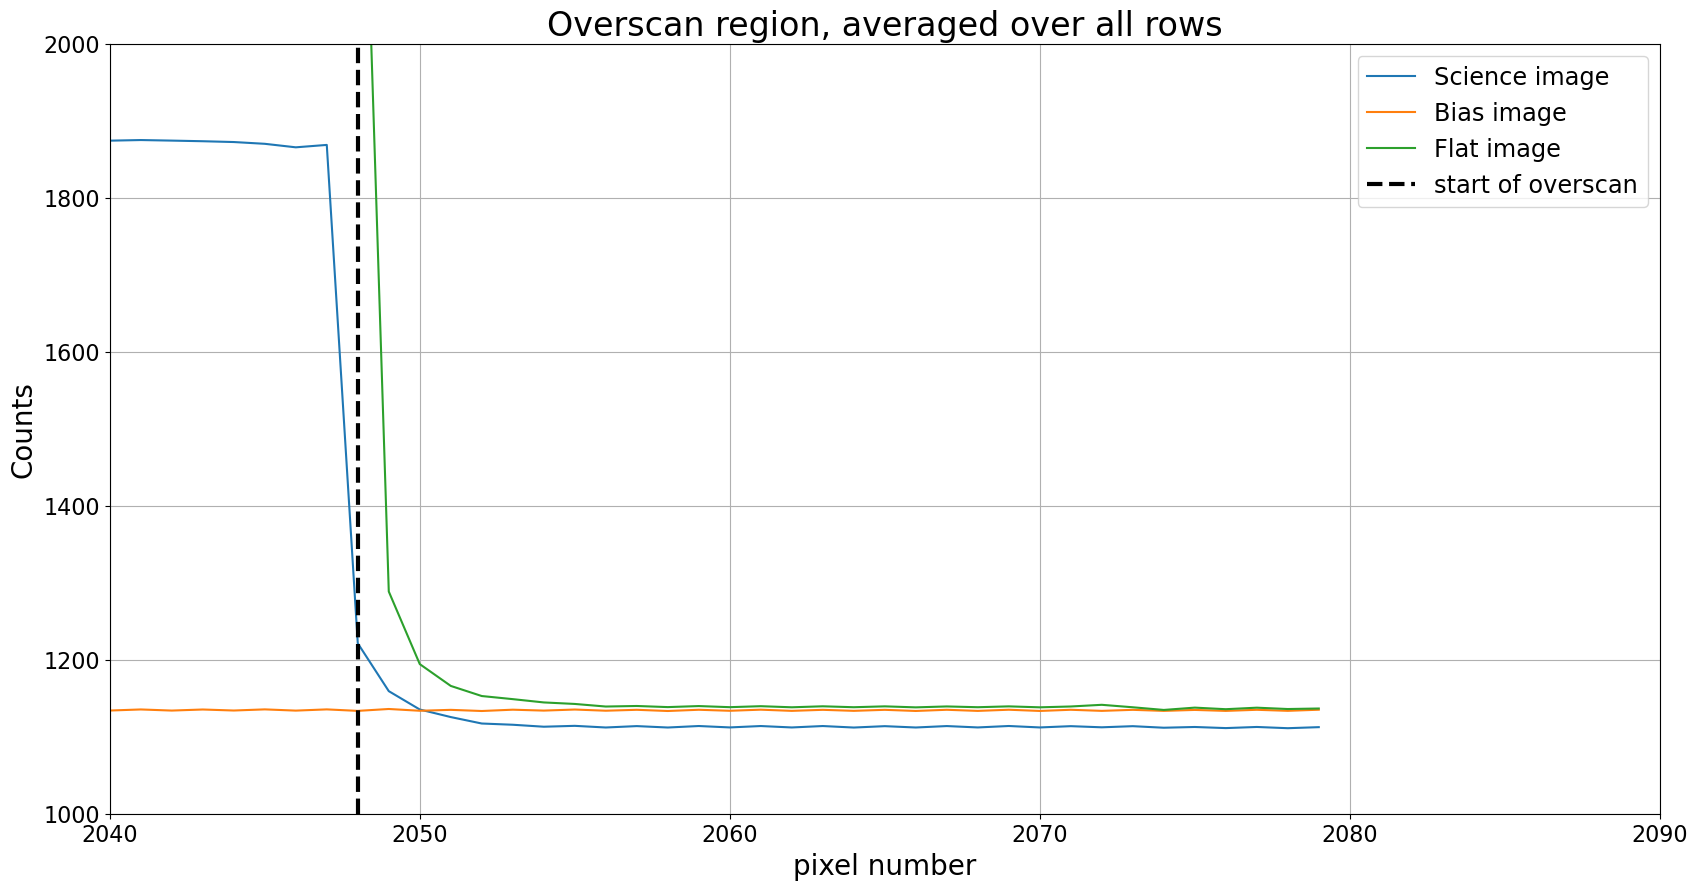

In [17]:
plt.figure(figsize=(20,10))
plt.plot(science_g_lfc.data.mean(axis=0), label='Science image')
plt.plot(bias_lfc.data.mean(axis=0), label='Bias image')
plt.plot(flat_g_lfc.data.mean(axis=0), label='Flat image')
plt.grid()

plt.axvline(x=2048, color='black', linewidth=3, linestyle='dashed', label='start of overscan')
plt.legend()

plt.ylim(1000, 2000)
plt.xlim(2040, 2090)
plt.xlabel('pixel number')
plt.ylabel('Counts')
plt.title('Overscan region, averaged over all rows')

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Notes
  </span>
</h1>

- Overscan é uma região do chip CCD que está coberta — nunca recebe luz. É como uma "faixa escura" nas bordas da imagem.

- BIASSEC = palavra-chave no header do arquivo FITS que diz onde está a região de overscan na imagem. É o fabricante da câmera (ou o software de aquisição) que escreve isso no header quando a imagem é salva.

- [cryo](https://github.com/astropy/ccd-reduction-and-photometry-guide/blob/ae5ec5f8cc73516faf1085c68a9fe1ecb33f4d23/notebooks/download_data.py#L80) tem que baixar, caso queira que rode

- matplotlib [axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html) & [pyplot](https://matplotlib.org/stable/tutorials/pyplot.html)

- Lembrar que:
    - overscan

---

<h1 style="text-align: left; font-family: 'menlo'; color: #191970; font-size:40px;">
  <span style="background-color: #ADD8E6; padding: 5px 10px; border-radius: 5px; display: inline-block;">
     Links
  </span>
</h1>

https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://github.com/nyny2903/astropy-coisas/tree/main<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-08-Overscan.html

https://matplotlib.org/stable/users/index.html<br>